# Chapter 2: Returns, Expected Return, and Volatility

This notebook demonstrates how to calculate investment returns and risk metrics using real market data.

In [20]:
# Import libraries
import sys
sys.path.append('../')

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import functions from chapter2_returns
from src.chapter2_returns import simple_return, log_return, expected_return, volatility
from src.data_utils import download_and_save_prices, load_prices_from_csv

## Download Historical Price Data

We'll download closing prices for UBS stock from Yahoo Finance.

In [21]:
# Download and save UBS prices
ticker = 'UBS'
start_date = '2022-01-01'
end_date = '2024-01-01'

# Download and save to CSV
prices, csv_file = download_and_save_prices(ticker, start_date, end_date, data_dir='../data')

print(f"\nNumber of trading days: {len(prices)}")
print(f"Price range: ${prices.min():.2f} - ${prices.max():.2f}")
print(f"\nFirst 5 prices:\n{prices[:5]}")

✓ Saved to ../data/UBS_2022-01-01_2024-01-01.csv

Number of trading days: 501
Price range: $12.86 - $29.43

First 5 prices:
[16.20974541 16.65703392 16.45128059 17.01486397 17.31007576]


## Load from Saved Data

If you already have the CSV file, use this instead:

```python
# prices = load_prices_from_csv('../data/UBS_2022-01-01_2024-01-01.csv')
```

## Calculate Simple Returns

Simple returns show percentage gain/loss day-to-day: $(P_t - P_{t-1}) / P_{t-1}$

In [22]:
# Calculate simple returns
simple_ret = simple_return(prices)

print(f"Number of returns: {len(simple_ret)}")
print(f"\nFirst 5 daily returns (%):\n{simple_ret[:5] * 100}")
print(f"\nReturn statistics:")
print(f"  Min: {simple_ret.min()*100:.3f}%")
print(f"  Max: {simple_ret.max()*100:.3f}%")
print(f"  Mean: {simple_ret.mean()*100:.3f}%")

Number of returns: 500

First 5 daily returns (%):
[ 2.75938025 -1.23523388  3.42577206  1.73502293 -0.56848878]

Return statistics:
  Min: -11.263%
  Max: 11.968%
  Mean: 0.142%


## Calculate Log Returns

Log returns: $\ln(P_t / P_{t-1})$ — Better for statistical analysis and additive over time.

In [23]:
# Calculate log returns
log_ret = log_return(prices)

print(f"First 5 log returns (%):\n{log_ret[:5] * 100}")
print(f"\nComparison (first 3 days):")
print(f"  Simple returns: {simple_ret[:3] * 100}")
print(f"  Log returns:    {log_ret[:3] * 100}")
print(f"\nDifference is small for small returns, but matters for large moves!")

First 5 log returns (%):
[ 2.72199552 -1.24292631  3.36839913  1.72014327 -0.57011082]

Comparison (first 3 days):
  Simple returns: [ 2.75938025 -1.23523388  3.42577206]
  Log returns:    [ 2.72199552 -1.24292631  3.36839913]

Difference is small for small returns, but matters for large moves!


## Calculate Expected Return and Volatility

Key metrics for investment decisions:
- **Expected Return**: Average return (expected value)
- **Volatility**: Standard deviation of returns (risk measure)

In [24]:
# Calculate expected return and volatility
exp_ret = expected_return(simple_ret)
vol = volatility(simple_ret)

# Annualize metrics (approximately 252 trading days per year)
annual_return = exp_ret * 252
annual_volatility = vol * np.sqrt(252)

print(f"UBS (UBSGN.SW) 2022-2024 Analysis")
print(f"=" * 40)
print(f"\nDaily metrics:")
print(f"  Expected return: {exp_ret*100:.4f}%")
print(f"  Volatility (std): {vol*100:.4f}%")
print(f"\nAnnualized metrics:")
print(f"  Expected return: {annual_return*100:.2f}%")
print(f"  Volatility:      {annual_volatility*100:.2f}%")
print(f"\nSharpe Ratio (assuming 0% risk-free rate): {annual_return/annual_volatility:.2f}")

UBS (UBSGN.SW) 2022-2024 Analysis

Daily metrics:
  Expected return: 0.1419%
  Volatility (std): 2.2173%

Annualized metrics:
  Expected return: 35.77%
  Volatility:      35.20%

Sharpe Ratio (assuming 0% risk-free rate): 1.02


## Visualize Price and Returns

Let's plot the price series and daily returns over time.

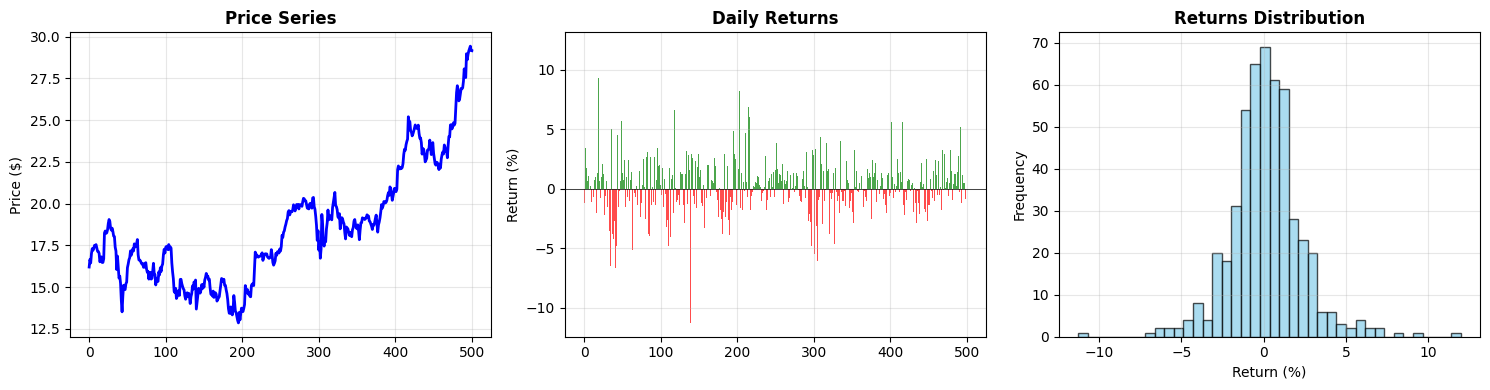

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Price Series
axes[0].plot(prices, linewidth=2, color='blue')
axes[0].set_title('Price Series', fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].grid(alpha=0.3)

# Plot 2: Daily Returns
axes[1].bar(range(len(simple_ret)), simple_ret * 100, color=['green' if x > 0 else 'red' for x in simple_ret], alpha=0.7, width=1)
axes[1].set_title('Daily Returns', fontweight='bold')
axes[1].set_ylabel('Return (%)')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].grid(alpha=0.3)

# Plot 3: Return Distribution
axes[2].hist(simple_ret * 100, bins=40, color='skyblue', edgecolor='black', alpha=0.7)
axes[2].set_title('Returns Distribution', fontweight='bold')
axes[2].set_xlabel('Return (%)')
axes[2].set_ylabel('Frequency')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

The notebook demonstrates:

1. **Data Collection**: Download historical prices from Yahoo Finance
2. **Return Calculation**: Compute simple and log returns from prices
3. **Risk Metrics**: Calculate expected return and volatility
4. **Annualization**: Scale daily metrics to annual figures (252 trading days)
5. **Visualization**: Plot price trends and return distributions

These foundational metrics are used in later chapters for portfolio construction (Chapter 3) and CAPM analysis (Chapter 5).